### Dependencies and Imports

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

### 1. Dataset Acquisition

In [2]:
print("Task 1: Acquiring Dataset...")
path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")
csv_file = os.path.join(path, "heart_failure_clinical_records_dataset.csv")
print(f"Dataset downloaded to: {csv_file}\n")

Task 1: Acquiring Dataset...
Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Dataset downloaded to: /kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv



### 2. Load Dataset

In [3]:
print("Task 2: Loading Dataset...")
df = pd.read_csv(csv_file)
print("First 5 rows:")
print(df.head(), "\n")

Task 2: Loading Dataset...
First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  

### 3. Summarize Dataset

In [4]:
print("Task 3: Summarizing Dataset...")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")
print("Data Types:\n", df.dtypes, "\n")
print("Missing Values per Column:\n", df.isnull().sum(), "\n")

stats_before = df.describe()

Task 3: Summarizing Dataset...
Number of Rows: 299
Number of Columns: 13

Data Types:
 age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object 

Missing Values per Column:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int6

### 4. Visualize Missing Values

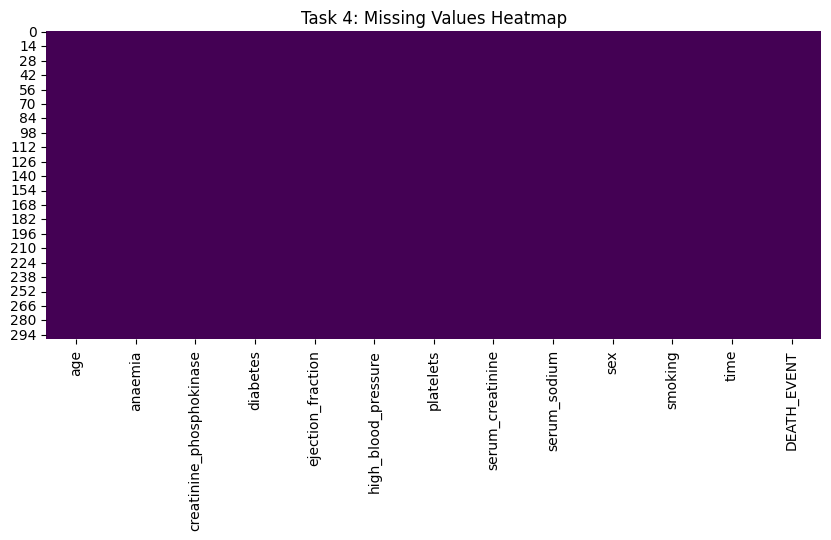

In [5]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Task 4: Missing Values Heatmap")
plt.show()

### 5. Plot Distributions

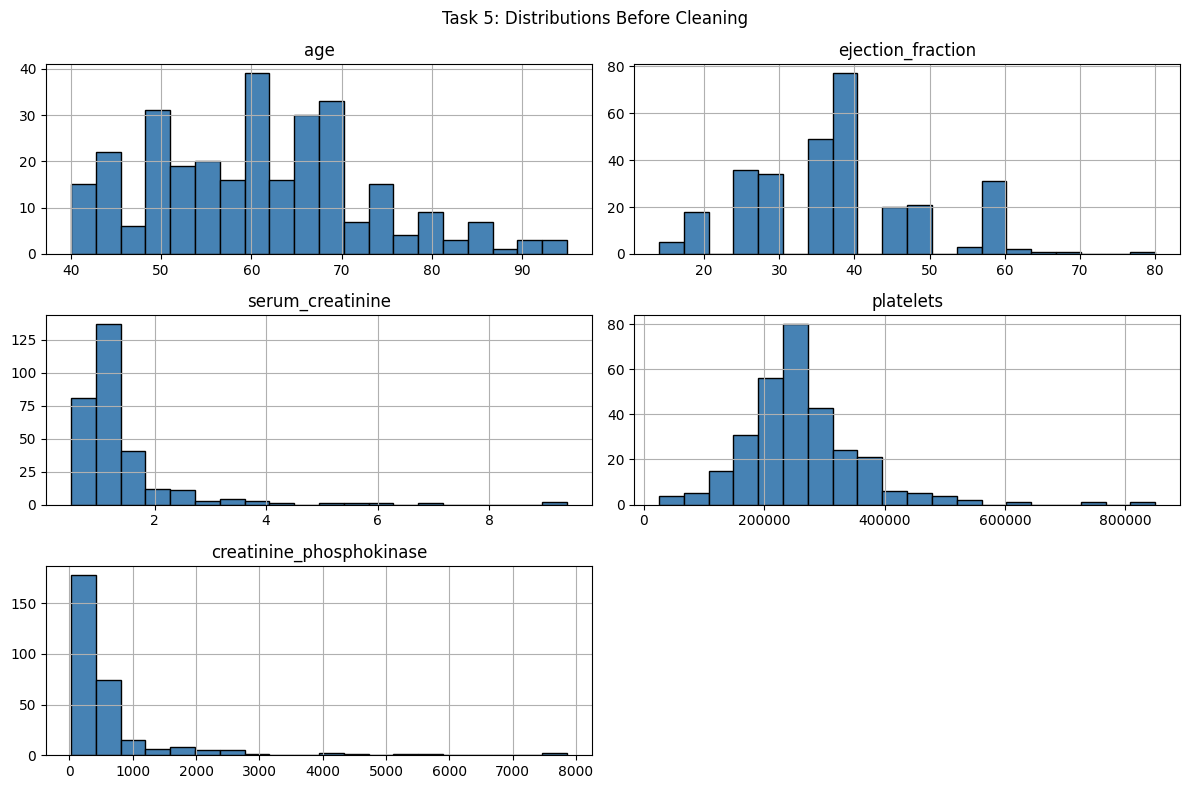

In [6]:
numerical_features = ['age', 'ejection_fraction', 'serum_creatinine', 'platelets', 'creatinine_phosphokinase']
df[numerical_features].hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle("Task 5: Distributions Before Cleaning")
plt.tight_layout()
plt.show()

### 6. Impute Missing Values

In [7]:
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

### 7. Remove Outliers

In [8]:
features_for_outlier_removal = ['ejection_fraction', 'serum_creatinine', 'platelets']

for col in features_for_outlier_removal:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Task 7: Rows remaining after outlier removal: {df.shape[0]}\n")

Task 7: Rows remaining after outlier removal: 251



### 8. Correct Inconsistencies

In [9]:
df['age'] = df['age'].apply(lambda x: abs(x) if x < 0 else x)

### 9. Feature Engineering

In [10]:
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 40, 60, float('inf')],
                         labels=['<40', '40-60', '>60'])

df['risk_score_raw'] = df['ejection_fraction'] * df['serum_creatinine']
scaler = MinMaxScaler()
df['risk_score'] = scaler.fit_transform(df[['risk_score_raw']])
df.drop(columns=['risk_score_raw'], inplace=True)

### 10. Encode Categorical Variables

In [11]:
df = pd.get_dummies(df, columns=['age_group'], drop_first=False)

one_hot_cols = [col for col in df.columns if 'age_group' in col]
df[one_hot_cols] = df[one_hot_cols].astype(int)

### 11. Normalize Features

In [12]:
features_to_scale = ['age', 'platelets', 'creatinine_phosphokinase', 'time']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

### 12. Compute Summary Statistics

In [13]:
stats_after = df.describe()

print("Task 12: Summary Statistics Comparison")
print("--- BEFORE Cleaning ---")
print(stats_before[['age', 'ejection_fraction', 'serum_creatinine']].loc[['mean', '50%', 'std']])
print("\n--- AFTER Cleaning ---")
print(stats_after[['age', 'ejection_fraction', 'serum_creatinine']].loc[['mean', '50%', 'std']], "\n")

Task 12: Summary Statistics Comparison
--- BEFORE Cleaning ---
            age  ejection_fraction  serum_creatinine
mean  60.833893          38.083612           1.39388
50%   60.000000          38.000000           1.10000
std   11.894809          11.834841           1.03451

--- AFTER Cleaning ---
           age  ejection_fraction  serum_creatinine
mean  0.369238          37.932271          1.130120
50%   0.363636          38.000000          1.100000
std   0.216335          11.540858          0.334718 



### 13. Validate Cleaning

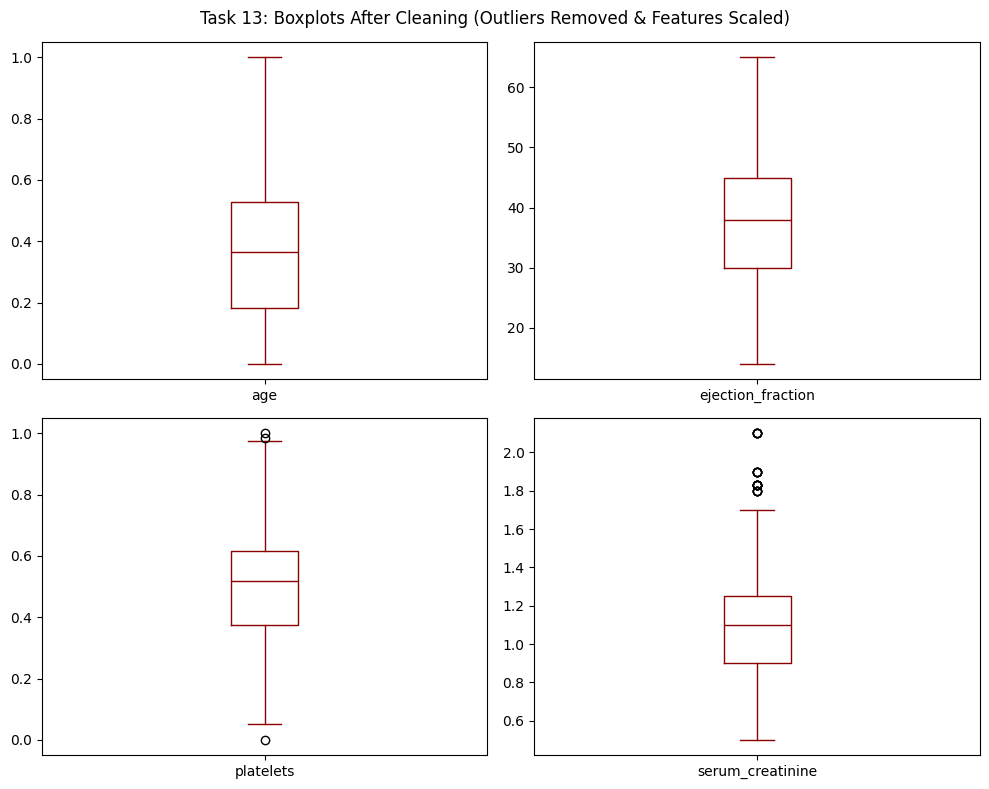

In [15]:
df[['age', 'ejection_fraction', 'platelets', 'serum_creatinine']].plot(
    kind='box',
    subplots=True,
    layout=(2,2),
    figsize=(10, 8),
    title="Task 13: Boxplots After Cleaning (Outliers Removed & Features Scaled)",
    color='darkred'
)
plt.tight_layout()
plt.show()

### 14. Check Missing Values

In [16]:
print("Task 14: Final Missing Values Check")
final_missing = df.isnull().sum().sum()
if final_missing == 0:
    print("Success: 0 missing values remain.")
else:
    print(f"Warning: {final_missing} missing values found.")

Task 14: Final Missing Values Check
Success: 0 missing values remain.


Final Clean Dataset

In [18]:
display(df.head(10))

df.info()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.070489,0,20,1,0.523529,1.9,130,1,0,0.000000,1,0.287245,0,0,1
1,0.272727,0,1.000000,0,38,0,0.518700,1.1,136,1,0,0.007117,1,0.327974,0,1,0
2,0.454545,0,0.014813,0,20,0,0.220588,1.3,129,1,1,0.010676,1,0.158628,0,0,1
3,0.181818,1,0.010344,0,20,0,0.361765,1.9,137,1,0,0.010676,1,0.287245,0,1,0
5,0.909091,1,0.002171,0,40,1,0.344118,2.1,132,1,1,0.014235,1,0.780279,0,0,1
6,0.636364,1,0.027583,0,15,0,0.117647,1.2,137,1,0,0.021352,1,0.072883,0,0,1
8,0.454545,0,0.016218,0,65,0,0.518700,1.5,138,0,0,0.021352,1,0.924973,0,0,1
11,0.400000,0,0.025667,0,25,1,0.488235,0.9,140,1,1,0.021352,1,0.121115,0,0,1
12,0.090909,1,0.121440,0,30,0,0.144118,1.1,137,1,0,0.024911,1,0.233655,0,1,0
13,0.181818,1,0.017622,0,38,1,0.555882,1.1,137,1,0,0.024911,1,0.327974,0,1,0


<class 'pandas.core.frame.DataFrame'>
Index: 251 entries, 0 to 298
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       251 non-null    float64
 1   anaemia                   251 non-null    int64  
 2   creatinine_phosphokinase  251 non-null    float64
 3   diabetes                  251 non-null    int64  
 4   ejection_fraction         251 non-null    int64  
 5   high_blood_pressure       251 non-null    int64  
 6   platelets                 251 non-null    float64
 7   serum_creatinine          251 non-null    float64
 8   serum_sodium              251 non-null    int64  
 9   sex                       251 non-null    int64  
 10  smoking                   251 non-null    int64  
 11  time                      251 non-null    float64
 12  DEATH_EVENT               251 non-null    int64  
 13  risk_score                251 non-null    float64
 14  age_group_<40  